
# Inteligência Computacional
## Estudo de Caso — Pré-processamento de Dados para Machine Learning

**Objetivo:** aplicar, em um problema realista de Ciência de Dados, as principais etapas de preparação de dados antes da modelagem.

### Cenário
Uma empresa de serviços por assinatura deseja prever quais clientes têm maior probabilidade de **cancelar o serviço** (`cancelou = 1`).

A base contém problemas comuns encontrados em projetos reais:

- valores ausentes;
- registros duplicados;
- categorias inconsistentes;
- tipos de dados incorretos;
- outliers;
- variáveis categóricas;
- atributos numéricos em escalas muito diferentes.

> A proposta não é apenas "limpar a base", mas justificar **por que** cada transformação é necessária e qual seu impacto potencial na modelagem.


## 1. Preparação do ambiente

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
np.random.seed(42)



## 2. Construção do conjunto de dados

Para tornar o notebook autocontido, vamos gerar uma base sintética que reproduz problemas frequentes em dados reais.

A variável-alvo será **`cancelou`**:

- `0` → cliente permaneceu;
- `1` → cliente cancelou.


In [2]:

n = 220

df = pd.DataFrame({
    "id_cliente": np.arange(1001, 1001+n),
    "idade": np.random.normal(38, 11, n).round(),
    "renda_mensal": np.random.normal(5200, 1900, n).round(2),
    "tempo_cliente_meses": np.random.randint(1, 72, n),
    "plano": np.random.choice(["Básico", "Intermediário", "Premium"], n, p=[0.45, 0.35, 0.20]),
    "cidade": np.random.choice(["Jundiaí", "Campinas", "São Paulo"], n, p=[0.35, 0.30, 0.35]),
    "chamados_suporte": np.random.poisson(2.2, n),
})

# Probabilidade de cancelamento: maior para pouco tempo de cliente,
# muitos chamados e plano básico.
score = (
    -0.03 * df["tempo_cliente_meses"]
    + 0.28 * df["chamados_suporte"]
    + 0.55 * (df["plano"] == "Básico").astype(int)
    - 0.00008 * df["renda_mensal"]
    + 0.35
)
prob = 1 / (1 + np.exp(-score))
df["cancelou"] = (np.random.rand(n) < prob).astype(int)

# Introdução proposital de problemas
df.loc[np.random.choice(df.index, 12, replace=False), "idade"] = np.nan
df.loc[np.random.choice(df.index, 10, replace=False), "renda_mensal"] = np.nan

# Categorias inconsistentes
df.loc[np.random.choice(df.index, 8, replace=False), "cidade"] = "são paulo"
df.loc[np.random.choice(df.index, 6, replace=False), "cidade"] = " SP "
df.loc[np.random.choice(df.index, 5, replace=False), "plano"] = "premium"

# Outliers
df.loc[np.random.choice(df.index, 3, replace=False), "renda_mensal"] = [28000, 35000, 42000]
df.loc[np.random.choice(df.index, 2, replace=False), "idade"] = [7, 112]

# Duplicidades
df = pd.concat([df, df.iloc[[4, 17, 44]]], ignore_index=True)

df.head()


,id_cliente,idade,renda_mensal,tempo_cliente_meses,plano,cidade,chamados_suporte,cancelou
0,1001,43.0,9597.85,69,Intermediário,Jundiaí,1,0
1,1002,36.0,1652.20,34,Básico,Jundiaí,4,1
2,1003,45.0,6503.89,6,Intermediário,São Paulo,2,1
3,1004,55.0,2135.84,53,Intermediário,Jundiaí,2,1
4,1005,NaN,4303.33,66,Intermediário,Jundiaí,6,1



## 3. Diagnóstico inicial

Antes de tratar, o cientista de dados deve **medir o problema**.

Perguntas orientadoras:

1. Quantas linhas e colunas existem?
2. Quais são os tipos de dados?
3. Há valores ausentes?
4. Existem registros duplicados?
5. As categorias estão padronizadas?
6. Existem valores extremos?


In [7]:

print("Dimensão:",df.shape)
display(df.head())
print("Tipos de dados:")
display(df.dtypes.to_frame("tipo"))
display(df.isna().sum().to_frame("Ausentes"))
print("Duplicidades:", df.duplicated().sum())


Dimensão: (223, 8)


,id_cliente,idade,renda_mensal,tempo_cliente_meses,plano,cidade,chamados_suporte,cancelou
0,1001,43.0,9597.85,69,Intermediário,Jundiaí,1,0
1,1002,36.0,1652.20,34,Básico,Jundiaí,4,1
2,1003,45.0,6503.89,6,Intermediário,São Paulo,2,1
3,1004,55.0,2135.84,53,Intermediário,Jundiaí,2,1
4,1005,NaN,4303.33,66,Intermediário,Jundiaí,6,1


Tipos de dados:


,tipo
id_cliente,int64
idade,float64
renda_mensal,float64
tempo_cliente_meses,int64
plano,object
cidade,object
chamados_suporte,int64
cancelou,int64


,Ausentes
id_cliente,0
idade,13
renda_mensal,10
tempo_cliente_meses,0
plano,0
cidade,0
chamados_suporte,0
cancelou,0


Duplicidades: 3


## 4. Valores ausentes — conceito e tratamento

,percentual
idade,5.83
renda_mensal,4.48
id_cliente,0.00
tempo_cliente_meses,0.00
plano,0.00
cidade,0.00
chamados_suporte,0.00
cancelou,0.00


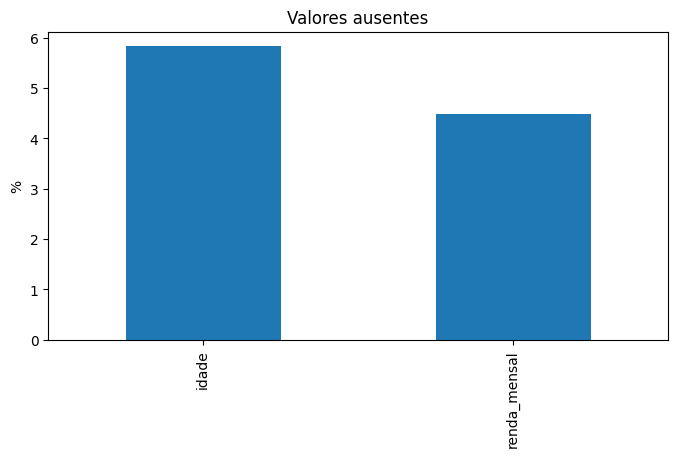

In [11]:

faltantes =(
    df.isna()
    .mean()
    .round(4)
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("percentual")
)

display(faltantes)
faltantes[faltantes["percentual"]>0].plot(
    kind="bar", legend=False, figsize=(8,4))
plt.title("Valores ausentes")
plt.ylabel("%");
plt.show()


### Decisão

- **Idade**: imputação pela **mediana**, por ser robusta a valores extremos.
- **Renda mensal**: também usaremos a **mediana**.
- Em projetos reais, a imputação deve considerar o mecanismo da ausência e o contexto de negócio.

> Remover linhas automaticamente nem sempre é a melhor decisão.


In [16]:
df_tratado = df.copy()
df_tratado["idade"].fillna(
    df_tratado["idade"].median(), inplace=True)
df_tratado["renda_mensal"].fillna(
    df_tratado["renda_mensal"].median(), inplace=True)
df_tratado.isna().sum()

/tmp/ipykernel_3856/3585275389.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tratado["idade"].fillna(
/tmp/ipykernel_3856/3585275389.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col

pandas.core.frame.DataFrame

## 5. Duplicidades e inconsistências

In [21]:
print("Duplicidades:", df_tratado.duplicated().sum())
df_tratado = df_tratado.drop_duplicates()
print("Duplicidades depois:", df_tratado.duplicated().sum())


Duplicidades: 3
Duplicidades depois: 0



### Padronização categórica

O mesmo conceito pode aparecer escrito de formas diferentes, criando categorias artificiais.

Exemplo:

`"São Paulo"`, `"são paulo"` e `" SP "` representam a mesma cidade.

O tratamento precisa ser **determinístico e documentado**.


In [22]:
df_tratado["cidade"].str.strip()

,cidade
0,Jundiaí
1,Jundiaí
2,São Paulo
3,Jundiaí
4,Jundiaí
...,...
215,São Paulo
216,Jundiaí
217,Jundiaí
218,Jundiaí


In [23]:
df_tratado["plano"].value_counts()

,count
plano,
Básico,89
Intermediário,82
Premium,44
premium,5


In [24]:
df_tratado["cidade"]=(
    df_tratado["cidade"]
    .str.strip()
    .str.lower()
    .str.replace("sp", "são paulo")
)

df_tratado["plano"] = (
    df_tratado["plano"]
    .str.strip()
    .str.lower()
)

display(df_tratado["plano"].value_counts())
display(df_tratado["cidade"].value_counts())

/tmp/ipykernel_3856/1234401741.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tratado["cidade"]=(
/tmp/ipykernel_3856/1234401741.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tratado["plano"] = (


,count
plano,
básico,89
intermediário,82
premium,49


,count
cidade,
são paulo,89
jundiaí,74
campinas,57


## 6. Outliers: detectar não significa remover

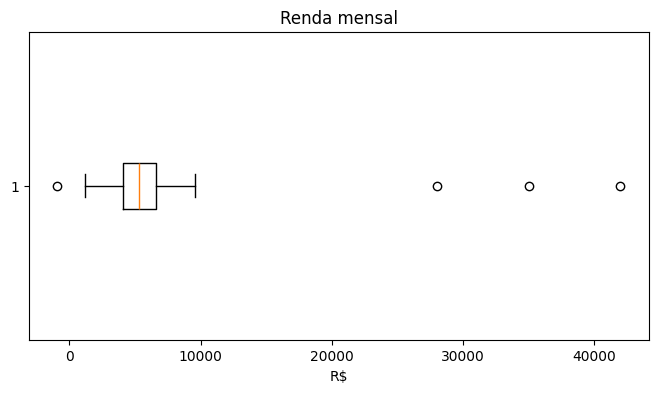

In [25]:

fig, ax = plt.subplots(figsize=(8,4))
ax.boxplot(df_tratado["renda_mensal"],vert=False)
ax.set_title("Renda mensal")
ax.set_xlabel("R$")
plt.show()


In [28]:
q1 = df_tratado["renda_mensal"].quantile(0.25)
q3 = df_tratado["renda_mensal"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_renda = df_tratado[
    (df_tratado["renda_mensal"] < limite_inferior) |
    (df_tratado["renda_mensal"] > limite_superior)
]

display(outliers_renda)

print(f"Limites IQR: {limite_inferior} a {limite_superior}")

,id_cliente,idade,renda_mensal,tempo_cliente_meses,plano,cidade,chamados_suporte,cancelou
42,1043,37.0,-958.41,61,básico,campinas,4,1
160,1161,27.0,42000.00,9,básico,jundiaí,2,1
191,1192,47.0,35000.00,17,básico,são paulo,0,1
199,1200,25.0,28000.00,67,premium,jundiaí,1,0


Limites IQR: 286.7562500000013 a 10351.88625



### Decisão sobre outliers

Neste estudo, **não removeremos automaticamente** os outliers de renda.

Justificativa:

- renda elevada pode ser um valor legítimo;
- remover observações raras pode eliminar informação relevante;
- a decisão deve considerar contexto, origem do dado e algoritmo utilizado.

Para **idade**, valores biologicamente ou operacionalmente implausíveis podem indicar erro de coleta.


In [30]:

df_tratado.loc[df_tratado["idade"] > 90, "idade"] = df_tratado["idade"].median()
df_tratado.loc[df_tratado["idade"] < 18, "idade"] =  df_tratado["idade"].median()
df_tratado.describe()

,id_cliente,idade,renda_mensal,tempo_cliente_meses,chamados_suporte,cancelou
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,1110.500000,38.881818,5730.275000,34.904545,2.218182,0.463636
std,63.652704,9.655464,3972.615681,21.298380,1.488966,0.499813
min,1001.000000,19.000000,-958.410000,1.000000,0.000000,0.000000
25%,1055.750000,33.000000,4061.180000,15.750000,1.000000,0.000000
50%,1110.500000,39.000000,5340.780000,34.500000,2.000000,0.000000
75%,1165.250000,44.000000,6577.462500,53.500000,3.000000,1.000000
max,1220.000000,80.000000,42000.000000,70.000000,7.000000,1.000000



## 7. Separação entre atributos e variável-alvo

A variável `id_cliente` é apenas um identificador. Em geral, ela **não deve ser usada como variável preditora**, pois não representa uma característica do fenômeno que queremos modelar.


In [31]:
X = df_tratado.drop(columns=["id_cliente", "cancelou"])
y = df_tratado["cancelou"]
display(X.head())
display(y.head())


,idade,renda_mensal,tempo_cliente_meses,plano,cidade,chamados_suporte
0,43.0,9597.85,69,intermediário,jundiaí,1
1,36.0,1652.20,34,básico,jundiaí,4
2,45.0,6503.89,6,intermediário,são paulo,2
3,55.0,2135.84,53,intermediário,jundiaí,2
4,39.0,4303.33,66,intermediário,jundiaí,6


,cancelou
0,0
1,1
2,1
3,1
4,1



## 8. Divisão treino e teste **antes** de aprender transformações

Esta etapa evita **data leakage**.

As estatísticas usadas na imputação, codificação ou escalonamento devem ser aprendidas **somente no conjunto de treinamento**.


## 9. Codificação e escalonamento


### Variáveis numéricas
Serão:

1. imputadas pela mediana;
2. padronizadas com **Z-score**.

Formalmente:

\[
z = \frac{x - \mu}{\sigma}
\]

### Variáveis categóricas
Serão:

1. imputadas pela moda;
2. transformadas com **One-Hot Encoding**.

A transformação será encapsulada em um `ColumnTransformer`, permitindo que o processo seja reproduzível.



## 10. Pipeline: pré-processamento + modelo

Uma prática recomendada é conectar preparação e modelagem em um único objeto.

Isso reduz:

- divergências entre treino e teste;
- esquecimento de etapas;
- risco de vazamento de dados;
- dificuldade de reprodução do experimento.



## 11. O que foi feito?

| Problema | Diagnóstico | Tratamento |
|---|---|---|
| Valores ausentes | `isna()` | imputação |
| Duplicidades | `duplicated()` | remoção |
| Categorias inconsistentes | `value_counts()` | padronização |
| Tipos / valores inválidos | inspeção e regras | conversão/correção |
| Outliers | boxplot + IQR | análise contextual |
| Variáveis categóricas | tipo `object` | One-Hot Encoding |
| Escalas diferentes | estatísticas descritivas | padronização |
| Data leakage | desenho do experimento | divisão antes do `fit` |



## 12. Discussão

Responda em grupo:

1. Por que não removemos automaticamente todos os outliers?
2. Quando a média seria melhor que a mediana para imputação?
3. Por que `id_cliente` foi removido das variáveis preditoras?
4. O que aconteceria se ajustássemos o `StandardScaler` usando toda a base antes da divisão treino/teste?
5. Em quais algoritmos o escalonamento tende a ser mais importante?
6. O tratamento feito aqui serviria exatamente igual para uma árvore de decisão? Justifique.



## 13. Desafio

Modifique o estudo de caso:

- crie uma nova variável com valores ausentes;
- introduza uma nova inconsistência categórica;
- aplique uma estratégia diferente de imputação;
- compare o resultado do modelo;
- registre a justificativa para cada decisão.

> **Próxima etapa da disciplina:** Engenharia de Atributos e preparação orientada à modelagem.
